# Aula 15 — Gráficos básicos com Matplotlib

**Módulo 5 — Visualização de Dados**

## Objetivos da aula

- Conhecer o Matplotlib, a biblioteca de visualização mais usada em Python.
- Criar gráficos de linha e de barras.
- Adicionar títulos, rótulos de eixos e outros elementos de comunicação visual.

---

## 1. Por que visualizar dados

`describe()` e `groupby()` (Aula 13) resumem os dados em números — mas o olho humano identifica padrões, tendências e valores fora da curva muito mais rápido em um **gráfico** do que em uma tabela. O **Matplotlib** é a biblioteca de visualização mais fundamental do ecossistema Python; mesmo bibliotecas mais modernas (Seaborn, Pandas `.plot()`) são construídas sobre ela.

## 2. Recriando a base de dados

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500
tipos_equipamento = ["Motor", "Bomba", "Compressor", "Ventilador"]

df = pd.DataFrame({
    "equipamento_id": [f"EQ-{i:04d}" for i in range(1, n + 1)],
    "tipo_equipamento": np.random.choice(tipos_equipamento, size=n),
    "temperatura": np.round(np.random.normal(70, 12, size=n), 1),
    "pressao": np.round(np.random.normal(5.5, 1.3, size=n), 2),
    "vibracao": np.round(np.random.normal(2.4, 1.1, size=n), 2),
    "horas_operacao": np.random.randint(0, 10000, size=n),
})


def definir_status(linha):
    critico = (linha["temperatura"] >= 90) or (linha["vibracao"] >= 4.5) or (linha["pressao"] >= 8) or (linha["pressao"] <= 2)
    alerta = (linha["temperatura"] >= 80) or (linha["vibracao"] >= 3.5) or (linha["pressao"] >= 7) or (linha["pressao"] <= 3)
    if critico:
        return "critico"
    elif alerta:
        return "alerta"
    else:
        return "normal"


df["status"] = df.apply(definir_status, axis=1)

,equipamento_id,tipo_equipamento,temperatura,pressao,vibracao,horas_operacao,status
0,EQ-0001,Compressor,59.8,6.42,3.01,1958,normal
1,EQ-0002,Ventilador,51.8,6.08,1.33,6344,normal
2,EQ-0003,Motor,64.6,5.03,2.52,5779,normal
3,EQ-0004,Compressor,80.3,7.01,0.93,6144,alerta
4,EQ-0005,Compressor,72.6,4.09,1.74,5063,normal


## 3. Importando o Matplotlib

In [2]:
import matplotlib.pyplot as plt

# no Jupyter/Colab, esta linha garante que os gráficos apareçam abaixo da célula
%matplotlib inline


## 4. Gráfico de linha

Gráficos de linha são ideais para mostrar a **evolução de um valor ao longo de uma sequência** — por exemplo, as leituras de temperatura de um único equipamento ao longo do tempo (aqui, usamos a ordem das leituras como um "tempo" simulado).

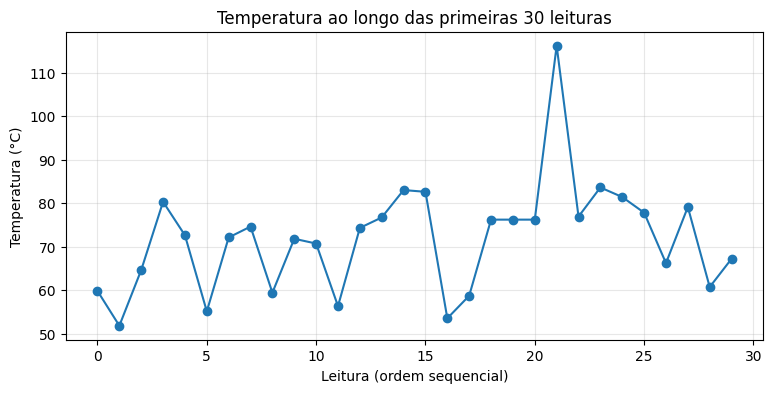

In [3]:
# como só temos uma leitura por equipamento nesta base, vamos usar as 30 primeiras
# leituras como se fossem uma sequência de medições ao longo do tempo
serie_temporal = df["temperatura"].head(30)

plt.figure(figsize=(9, 4))
plt.plot(serie_temporal.values, marker="o")
plt.title("Temperatura ao longo das primeiras 30 leituras")
plt.xlabel("Leitura (ordem sequencial)")
plt.ylabel("Temperatura (°C)")
plt.grid(True, alpha=0.3)
plt.show()


**Elementos usados:**

- `plt.figure(figsize=(largura, altura))` define o tamanho do gráfico, em polegadas.
- `plt.plot(valores, marker="o")` desenha a linha, com um marcador circular em cada ponto.
- `plt.title()`, `plt.xlabel()`, `plt.ylabel()` adicionam texto explicativo — **nunca deixe de nomear os eixos**, ou o gráfico perde significado para quem o vê depois.
- `plt.grid()` adiciona uma grade de fundo, facilitando a leitura dos valores.
- `plt.show()` renderiza o gráfico.

## 5. Gráfico de barras

Gráficos de barras comparam **quantidades entre categorias** — por exemplo, quantos equipamentos existem de cada tipo, ou a temperatura média por status.

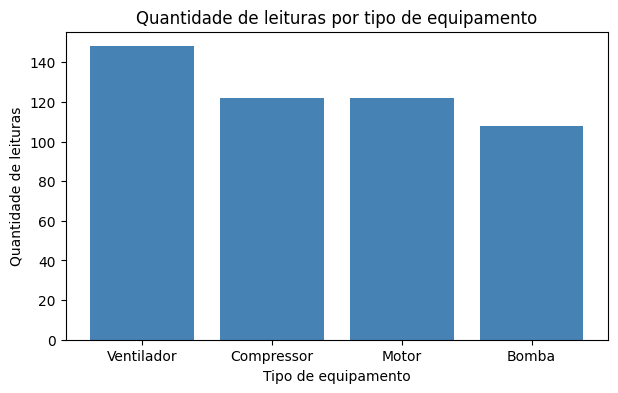

In [4]:
contagem_por_tipo = df["tipo_equipamento"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(contagem_por_tipo.index, contagem_por_tipo.values, color="steelblue")
plt.title("Quantidade de leituras por tipo de equipamento")
plt.xlabel("Tipo de equipamento")
plt.ylabel("Quantidade de leituras")
plt.show()


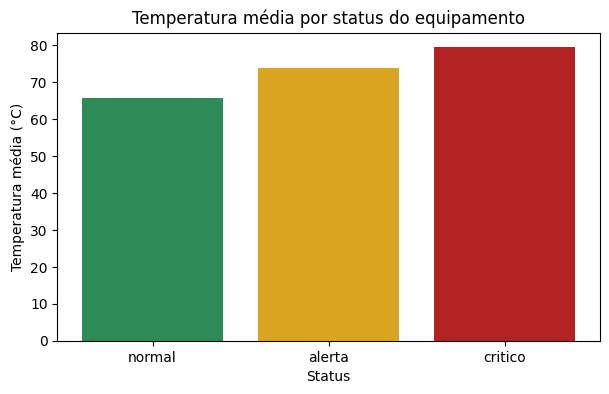

In [5]:
media_temperatura_por_status = df.groupby("status")["temperatura"].mean().reindex(["normal", "alerta", "critico"])

plt.figure(figsize=(7, 4))
cores = ["seagreen", "goldenrod", "firebrick"]
plt.bar(media_temperatura_por_status.index, media_temperatura_por_status.values, color=cores)
plt.title("Temperatura média por status do equipamento")
plt.xlabel("Status")
plt.ylabel("Temperatura média (°C)")
plt.show()


## 6. Múltiplas séries no mesmo gráfico, com legenda

Quando comparamos mais de uma série, `plt.legend()` identifica cada uma delas.

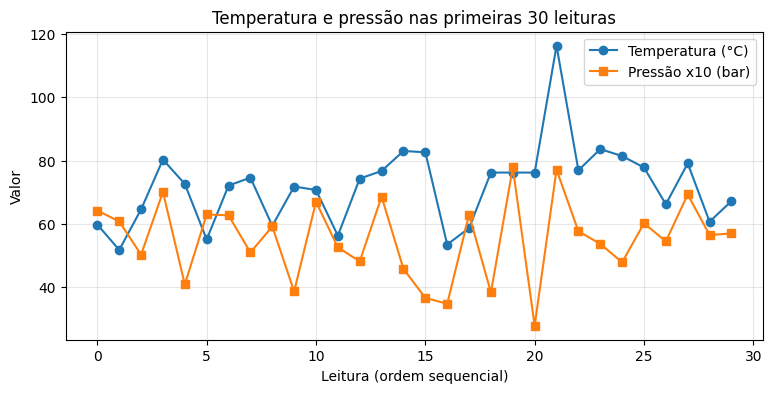

In [6]:
primeiras_leituras = df.head(30)

plt.figure(figsize=(9, 4))
plt.plot(primeiras_leituras["temperatura"].values, label="Temperatura (°C)", marker="o")
plt.plot(primeiras_leituras["pressao"].values * 10, label="Pressão x10 (bar)", marker="s")   # escala ajustada só para comparação visual
plt.title("Temperatura e pressão nas primeiras 30 leituras")
plt.xlabel("Leitura (ordem sequencial)")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Salvando um gráfico como imagem

`plt.savefig()` salva a última figura criada em um arquivo de imagem — útil para incluir o gráfico em um relatório.

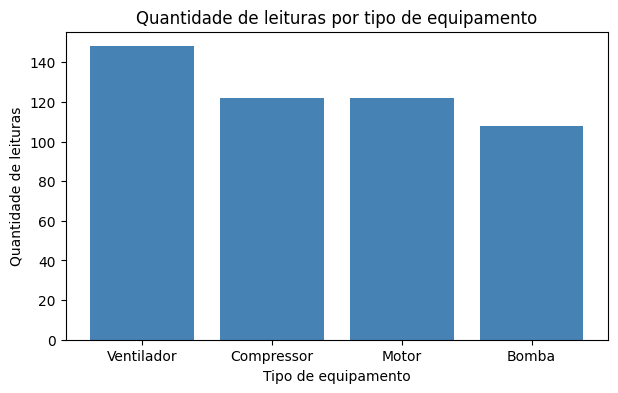

Gráfico salvo como 'grafico_tipos_equipamento.png'


In [7]:
plt.figure(figsize=(7, 4))
plt.bar(contagem_por_tipo.index, contagem_por_tipo.values, color="steelblue")
plt.title("Quantidade de leituras por tipo de equipamento")
plt.xlabel("Tipo de equipamento")
plt.ylabel("Quantidade de leituras")
plt.savefig("grafico_tipos_equipamento.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo como 'grafico_tipos_equipamento.png'")


## 8. Resumo da aula

- `import matplotlib.pyplot as plt` é o padrão de importação do Matplotlib.
- `plt.plot()` cria gráficos de linha (bom para sequências/tendências); `plt.bar()` cria gráficos de barras (bom para comparar categorias).
- `title`, `xlabel`, `ylabel` e `legend` tornam o gráfico compreensível sem precisar de explicação externa.
- `plt.savefig()` exporta o gráfico como imagem.

### Exercício sugerido

Crie um gráfico de barras mostrando a **quantidade de equipamentos por status** (`normal`, `alerta`, `crítico`), com uma cor diferente para cada barra e título explicativo.
